In [1]:
import torch
import torchvision
import torchvision.transforms.functional as VF
import matplotlib.pyplot as plt
import os
from torchvision.utils import draw_bounding_boxes, draw_keypoints

from eval_datasets.dataloaders import load_search_target_all_examples, load_image_nvjpegl_cpu
from project_definitions import ROOT_DIR
import project_utils

# Load model

In [2]:
# TODO: select one of the configs
import experiments.hr_insdet.cf_gap_grounding_dino as config
# import experiments.hr_insdet.cf_gap_stt as config
# import experiments.hr_insdet.cf_gap_mobilesam as config

In [ ]:
# TODO: if only glimpse locations are to be inspected, set 'with_downstream_arch' to False  
model = config.get_model(with_downstream_arch=True) 

# Load scene and search target examples

In [4]:
scene = load_image_nvjpegl_cpu(os.path.join(ROOT_DIR, 'experiments/demo_samples/scene.jpg'))
scene = VF.resize(scene, config.SCENE_SIZE) 

search_targets = load_search_target_all_examples(
    os.path.join(ROOT_DIR, 'experiments/demo_samples/search_target'), 
    resize=config.SEARCH_TARGET_SIZE, include_mask=True)

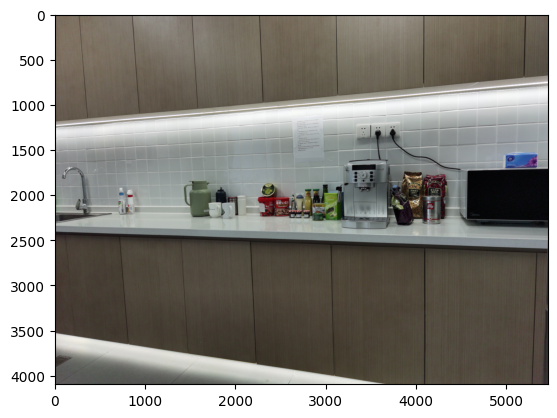

In [5]:
plt.imshow(scene.permute(1, 2, 0))

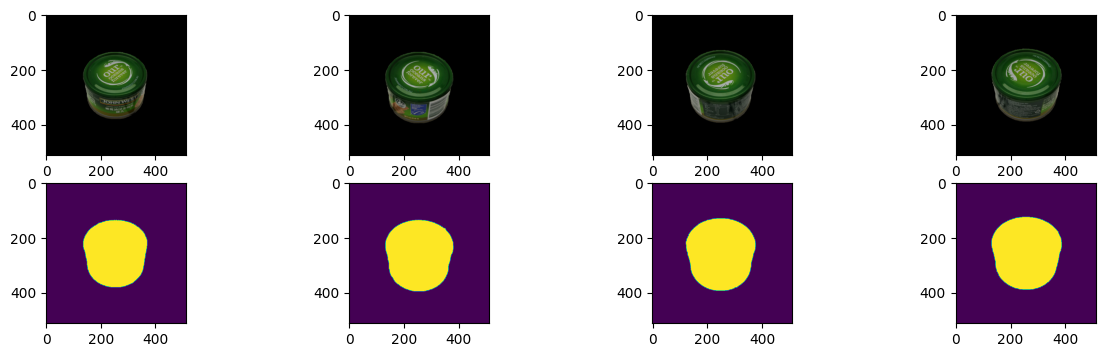

In [6]:
N_exmpl = search_targets.shape[0]
fig, axs = plt.subplots(2, N_exmpl//6, figsize=(15, 4))
for i, exmpl_idx in enumerate(range(0, N_exmpl, 6)):
    axs[0, i].imshow(search_targets[exmpl_idx, :3].permute(1, 2, 0))
    axs[1, i].imshow(search_targets[exmpl_idx, 3])

# Run model

In [ ]:
_, pred_bounding_box, aux_dict = model(scene[None].to(config.DEVICE), search_targets[None].to(config.DEVICE))
all_glimpse_locs = aux_dict['loc_hist'].cpu()     # [B, N_c, 1+N_f, 2] 
coarse_glimpse_locs = all_glimpse_locs[0, :, :1]
fine_glimpse_locs = all_glimpse_locs[0, :, 1:]

# Visualize result

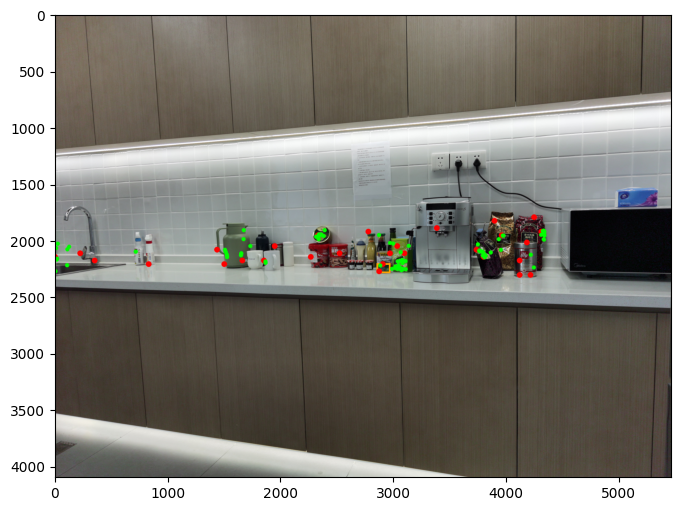

In [9]:
plotted_scene = scene.clone()
if pred_bounding_box is not None:   
    # if downstream architecture is used
    plotted_scene = draw_bounding_boxes(plotted_scene, pred_bounding_box.cpu(), colors='orange', width=15)    

# plot coarse glimpses in red
plotted_scene = draw_keypoints(
    plotted_scene, 
    project_utils.from_normalized_to_pixel_based(coarse_glimpse_locs, plotted_scene.shape[-2:]),
    colors="red", radius=25
)

# plot fine glimpses in lime
plotted_scene = draw_keypoints(
    plotted_scene, 
    project_utils.from_normalized_to_pixel_based(fine_glimpse_locs, scene.shape[-2:]),
    colors="lime", radius=18
)
plt.figure(figsize=(10, 6))
plt.imshow(plotted_scene.permute(1, 2, 0))